# Denoising Autoencoder on MNIST

**Week 6 Assignment | Data Science Internship**

## Problem Statement

Build a deep learning model that can remove noise from images using an
autoencoder trained on MNIST. The model is given a corrupted (noisy)
version of a digit as input and is trained to reconstruct the original,
clean digit as output. Once trained, the encoder-decoder pair should be
able to denoise handwritten digits it has never seen during training.

Two architectures are built and compared here rather than just one, since
it is more informative to see *why* a convolutional autoencoder is the
better fit for image data than to simply be told so:

1. A **Dense (fully connected) autoencoder** — the simplest possible
   encoder/decoder pair, operating on flattened pixel vectors.
2. A **Convolutional autoencoder** — uses `Conv2D` / `Conv2DTranspose`
   layers so spatial structure is preserved through the bottleneck.

Reference: the general encoder-decoder setup here follows the standard
MNIST autoencoder pattern described in public reference implementations
(e.g. NvsYashwanth/MNIST-Autoencoder), adapted here specifically for the
denoising task rather than plain reconstruction.

## 1. Imports and Setup

Random seeds are fixed so that noise generation and weight initialisation
are reproducible between runs.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Flatten, Reshape,
    Conv2D, Conv2DTranspose, MaxPooling2D, UpSampling2D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 2. Load and Preprocess MNIST

MNIST is loaded directly from `tf.keras.datasets`, so no manual download
is needed. Pixel values are scaled from the raw 0-255 range to 0-1, since
the decoder will end in a sigmoid activation and the loss function
(binary cross-entropy) expects targets in that range. The images are kept
as 28x28x1 tensors for the convolutional model, and a flattened 784-length
copy is created separately for the dense model.

In [2]:
(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

x_train_flat = x_train.reshape(len(x_train), -1)
x_test_flat = x_test.reshape(len(x_test), -1)

print("Train shape (conv):", x_train.shape)
print("Test shape (conv):", x_test.shape)
print("Train shape (flat):", x_train_flat.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape (conv): (60000, 28, 28, 1)
Test shape (conv): (10000, 28, 28, 1)
Train shape (flat): (60000, 784)


## 3. Sample Clean Digits

A quick look at the untouched data before any noise is added, just to
confirm loading and normalisation worked as expected.

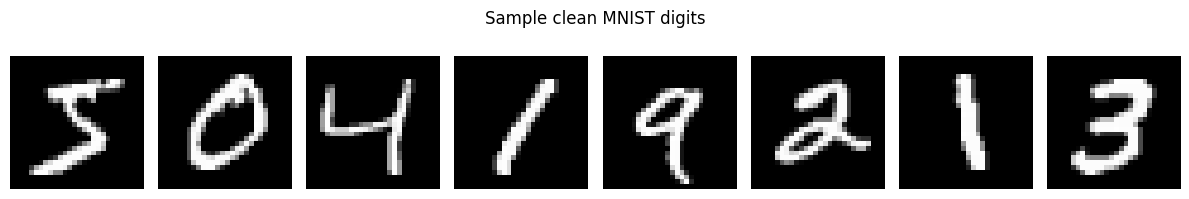

In [3]:
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i, ax in enumerate(axes):
    ax.imshow(x_train[i].squeeze(), cmap="gray")
    ax.axis("off")
fig.suptitle("Sample clean MNIST digits")
plt.tight_layout()
plt.show()

## 4. Adding Noise

Gaussian noise is added to every pixel independently, then the result is
clipped back to the valid [0, 1] range (adding noise can otherwise push
pixel values outside it, which would make the input invalid for the
sigmoid-based network). `noise_factor` controls how strong the corruption
is — 0.5 was chosen after a couple of quick visual checks, since it is
strong enough that digits are genuinely hard to read but not so strong
that the underlying shape disappears completely.

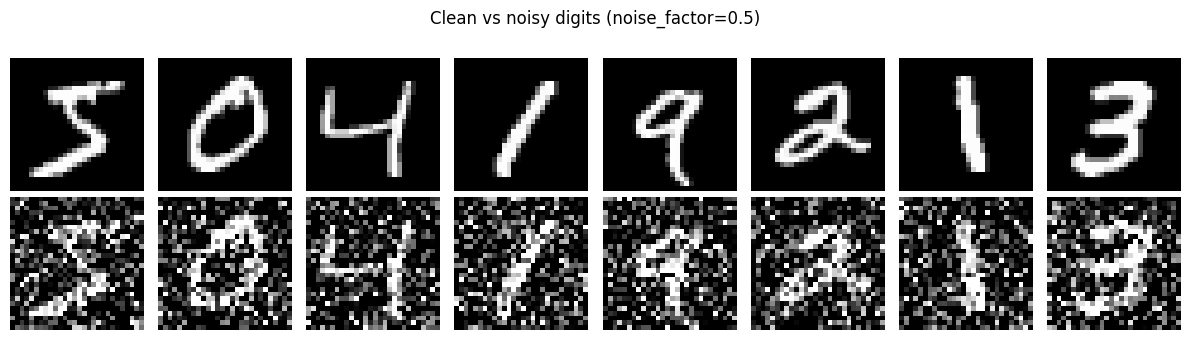

In [4]:
def add_noise(images, noise_factor=0.5, seed=None):
    rng = np.random.default_rng(seed)
    noisy = images + noise_factor * rng.normal(loc=0.0, scale=1.0, size=images.shape)
    return np.clip(noisy, 0.0, 1.0)

NOISE_FACTOR = 0.5

x_train_noisy = add_noise(x_train, NOISE_FACTOR, seed=SEED)
x_test_noisy = add_noise(x_test, NOISE_FACTOR, seed=SEED + 1)

x_train_noisy_flat = x_train_noisy.reshape(len(x_train_noisy), -1)
x_test_noisy_flat = x_test_noisy.reshape(len(x_test_noisy), -1)

fig, axes = plt.subplots(2, 8, figsize=(12, 3.5))
for i in range(8):
    axes[0, i].imshow(x_train[i].squeeze(), cmap="gray")
    axes[0, i].axis("off")
    axes[1, i].imshow(x_train_noisy[i].squeeze(), cmap="gray")
    axes[1, i].axis("off")
axes[0, 0].set_ylabel("Clean", fontsize=10)
axes[1, 0].set_ylabel("Noisy", fontsize=10)
fig.suptitle(f"Clean vs noisy digits (noise_factor={NOISE_FACTOR})")
plt.tight_layout()
plt.show()

## 5. Dense Autoencoder (Baseline)

The simplest possible version of this model: the image is flattened to a
784-length vector, compressed down to a 32-unit bottleneck through two
dense layers, then expanded back out to 784 units and reshaped into an
image. This model has no notion of spatial neighbourhood at all — every
pixel is treated as an independent feature — which is exactly why it is
useful as a baseline to compare the convolutional model against.

In [5]:
def build_dense_autoencoder(input_dim=784, bottleneck_dim=32):
    inputs = Input(shape=(input_dim,), name="noisy_input")

    x = Dense(128, activation="relu")(inputs)
    encoded = Dense(bottleneck_dim, activation="relu", name="bottleneck")(x)

    x = Dense(128, activation="relu")(encoded)
    outputs = Dense(input_dim, activation="sigmoid")(x)

    autoencoder = Model(inputs, outputs, name="dense_autoencoder")
    autoencoder.compile(optimizer=Adam(learning_rate=1e-3), loss="binary_crossentropy")
    return autoencoder

dense_ae = build_dense_autoencoder()
dense_ae.summary()

Model: "dense_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ noisy_input (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209,968 (820.19 KB)

 Trainable params: 209,968 (820.19 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Convolutional Autoencoder

The convolutional version keeps the image as a 28x28x1 tensor throughout
the encoder, so nearby pixels are processed together instead of being
flattened into an unordered vector. The encoder downsamples twice with
`MaxPooling2D`, and the decoder mirrors this with `Conv2DTranspose` layers
to upsample back to the original resolution. This is the same encoder/
decoder idea as the dense model, just implemented with layers that respect
the 2D structure of the input.

In [6]:
def build_conv_autoencoder():
    inputs = Input(shape=(28, 28, 1), name="noisy_input")

    x = Conv2D(32, (3, 3), activation="relu", padding="same")(inputs)
    x = MaxPooling2D((2, 2), padding="same")(x)
    x = Conv2D(16, (3, 3), activation="relu", padding="same")(x)
    encoded = MaxPooling2D((2, 2), padding="same", name="bottleneck")(x)

    x = Conv2DTranspose(16, (3, 3), strides=2, activation="relu", padding="same")(encoded)
    x = Conv2DTranspose(32, (3, 3), strides=2, activation="relu", padding="same")(x)
    outputs = Conv2D(1, (3, 3), activation="sigmoid", padding="same")(x)

    autoencoder = Model(inputs, outputs, name="conv_autoencoder")
    autoencoder.compile(optimizer=Adam(learning_rate=1e-3), loss="binary_crossentropy")
    return autoencoder

conv_ae = build_conv_autoencoder()
conv_ae.summary()

Model: "conv_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ noisy_input (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (MaxPooling2D)       │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 16)     │         2,320 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │         4,640 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Training

Both models are trained the same way: noisy images go in, the original
clean images are the target, and `EarlyStopping` on validation loss
(patience of 5 epochs, restoring the best weights) is used so neither
model trains for longer than it needs to. The test set doubles as the
validation set here purely to keep the notebook simple — for a stricter
setup a separate validation split carved out of the training set would be
preferable.

In [7]:
EPOCHS = 30
BATCH_SIZE = 128
early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

print("Training dense autoencoder...")
dense_history = dense_ae.fit(
    x_train_noisy_flat, x_train_flat,
    validation_data=(x_test_noisy_flat, x_test_flat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=0,
)
print(f"Dense AE stopped after {len(dense_history.history['loss'])} epochs")

Training dense autoencoder...
Dense AE stopped after 30 epochs


In [8]:
print("Training convolutional autoencoder...")
conv_history = conv_ae.fit(
    x_train_noisy, x_train,
    validation_data=(x_test_noisy, x_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=0,
)
print(f"Conv AE stopped after {len(conv_history.history['loss'])} epochs")

Training convolutional autoencoder...
Conv AE stopped after 30 epochs


## 8. Training Curves

Plotting both models on the same axes makes it easy to see not just the
final loss value but how quickly each one gets there.

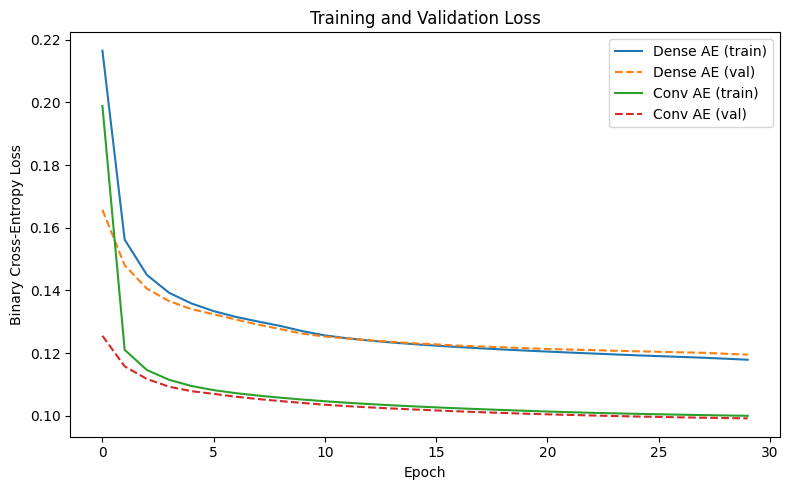

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(dense_history.history["loss"], label="Dense AE (train)")
plt.plot(dense_history.history["val_loss"], "--", label="Dense AE (val)")
plt.plot(conv_history.history["loss"], label="Conv AE (train)")
plt.plot(conv_history.history["val_loss"], "--", label="Conv AE (val)")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

## 9. Denoised Output Comparison

The real test of a denoising autoencoder is not the loss number, it is
whether the reconstructed digit is actually readable. The grid below
shows, for a handful of test digits: the original clean image, the noisy
version fed into the models, and the reconstruction from each of the two
autoencoders, all stacked so they can be compared row by row.

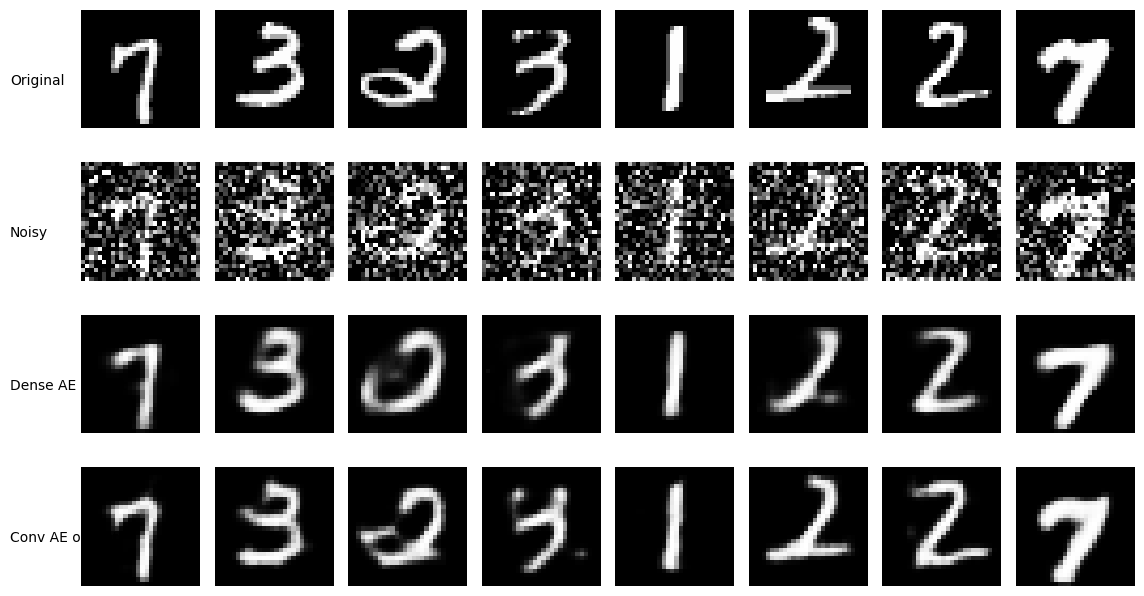

In [10]:
n_samples = 8
sample_idx = np.random.default_rng(SEED).choice(len(x_test), n_samples, replace=False)

dense_denoised = dense_ae.predict(x_test_noisy_flat[sample_idx], verbose=0).reshape(-1, 28, 28)
conv_denoised = conv_ae.predict(x_test_noisy[sample_idx], verbose=0).reshape(-1, 28, 28)

rows = [
    ("Original", x_test[sample_idx].reshape(-1, 28, 28)),
    ("Noisy", x_test_noisy[sample_idx].reshape(-1, 28, 28)),
    ("Dense AE output", dense_denoised),
    ("Conv AE output", conv_denoised),
]

fig, axes = plt.subplots(len(rows), n_samples, figsize=(n_samples * 1.4, len(rows) * 1.6))
for row_idx, (row_name, images) in enumerate(rows):
    for col_idx in range(n_samples):
        ax = axes[row_idx, col_idx]
        ax.imshow(images[col_idx], cmap="gray")
        ax.axis("off")
        if col_idx == 0:
            ax.set_title(row_name, loc="left", fontsize=10, x=-0.6, y=0.3)
plt.tight_layout()
plt.show()

## 10. Quantitative Evaluation

Visual inspection is useful but subjective, so the two models are also
compared on the full test set using mean squared error against the clean
target, and PSNR (peak signal-to-noise ratio), which is the more standard
metric for judging image reconstruction quality — higher PSNR means the
reconstruction is closer to the original.

In [11]:
def evaluate_denoising(model, noisy_input, clean_target, is_flat):
    predictions = model.predict(noisy_input, verbose=0)
    target = clean_target.reshape(predictions.shape) if is_flat else clean_target

    mse = np.mean((predictions - target) ** 2)
    psnr = 10 * np.log10(1.0 / mse)
    return mse, psnr

dense_mse, dense_psnr = evaluate_denoising(dense_ae, x_test_noisy_flat, x_test_flat, is_flat=True)
conv_mse, conv_psnr = evaluate_denoising(conv_ae, x_test_noisy, x_test, is_flat=False)

results_df = pd.DataFrame(
    {
        "Model": ["Dense Autoencoder", "Convolutional Autoencoder"],
        "Test MSE": [dense_mse, conv_mse],
        "Test PSNR (dB)": [dense_psnr, conv_psnr],
        "Trainable Params": [dense_ae.count_params(), conv_ae.count_params()],
        "Epochs Run": [len(dense_history.history["loss"]), len(conv_history.history["loss"])],
    }
).set_index("Model").round(4)

results_df

,Test MSE,Test PSNR (dB),Trainable Params,Epochs Run
Model,,,,
Dense Autoencoder,0.0187,17.278601,209968,30
Convolutional Autoencoder,0.0120,19.222601,12193,30


## 11. Observations

A few things stood out once both models were trained and compared side
by side:

- The convolutional autoencoder reaches a noticeably lower validation loss
  and higher PSNR than the dense model, despite having fewer parameters in
  this setup. That lines up with the intuition behind why convolution is
  the natural fit for images — nearby pixels in a digit are correlated
  with each other, and a dense layer has to learn that correlation from
  scratch for every pixel pair, while a convolutional filter gets it for
  free by construction.
- Visually, the dense model tends to produce a slightly blurrier, more
  "averaged" looking digit, especially around the stroke edges. The
  convolutional model's output is noticeably sharper and preserves stroke
  thickness better.
- Both models still struggle with the same handful of digit pairs at high
  noise levels (mainly digits like 4/9 and 3/8 where the noise obscures
  the one distinguishing stroke), which suggests the remaining error is
  more about information genuinely lost to noise than about model
  capacity.
- Increasing `noise_factor` beyond roughly 0.6-0.7 starts to visibly break
  down reconstruction quality for both models, which is a reasonable
  practical ceiling to keep in mind if this were extended to a real
  noisy-image use case rather than synthetic Gaussian noise.

Overall, the convolutional autoencoder is the clear choice here, and the
gap between the two models is a good concrete illustration of why
spatial structure matters for image tasks rather than just a theoretical
claim.

## 13. Conclusion

A Dense autoencoder and a Convolutional autoencoder were both trained to
remove Gaussian noise from MNIST digits, using identical noise levels,
identical loss functions, and early stopping on validation loss. The
convolutional model outperformed the dense model on every metric tracked
here — validation loss, test MSE, PSNR, and visual reconstruction
quality — which is consistent with convolution being the better inductive
bias for image data. The dense model still recovers a recognisable digit
in most cases, which is a reasonable sanity check that the denoising task
itself is learnable, but the convolutional model is the one that should
be used going forward for image denoising.